**Plant Disease Classification**

In [ ]:
# Run this cell to restore your dataset folders if your runtime ever disconnects or restarts!
import os
import kagglehub

# 1. Re-download the dataset structure
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
path1 = os.listdir(path)
path2 = os.path.join(path, path1[0])
path3 = os.path.join(path2, os.listdir(path2)[0])

train_path = os.path.join(path3, 'train')
val_path = os.path.join(path3, 'valid')

print("Dataset successfully restored!")
print("Train directory:", train_path)
print("Validation directory:", val_path)

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import models, transforms
import cv2
from sklearn.preprocessing import LabelEncoder
from torchvision import datasets
from torch.utils.data import DataLoader

In [2]:
import torch
import torch.nn as nn
from torchvision import models

class PlantDiseaseClassifier(nn.Module):
    def __init__(self, num_classes=38):
        super().__init__()

        # Load pre-trained EfficientNet-B0 backbone
        # Using weights='DEFAULT' is the modern PyTorch way instead of pretrained=True
        self.model = models.efficientnet_b0(weights='DEFAULT')

        # Get the input dimension of the original classifier's linear layer
        in_features = self.model.classifier[1].in_features

        # Replace the original classifier with an Identity layer
        # This effectively makes the backbone return the features after pooling
        self.model.classifier = nn.Identity()

        # Custom Multi-layer Perceptron (MLP) for plant disease classification
        # First Fully Connected layer
        self.fc1 = nn.Linear(in_features, 512)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.4)

        # Second Fully Connected layer
        self.fc2 = nn.Linear(512, 128)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.3)

        # Output layer for the 38 disease classes
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Extract features using the EfficientNet backbone
        x = self.model(x)

        # Pass features through the custom classifier head
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.drop2(x)

        # Return raw logits (CrossEntropyLoss will handle the Softmax internally)
        x = self.fc3(x)
        return x

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [5]:
import kagglehub

# Download the dataset
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
print("Path to dataset files:", path)

# List contents of the downloaded directory
path1 = os.listdir(path)
path1

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Path to dataset files: /kaggle/input/new-plant-diseases-dataset


['New Plant Diseases Dataset(Augmented)',
 'new plant diseases dataset(augmented)',
 'test']

In [6]:
path2=os.path.join(path,path1[0])
os.listdir(path2)

['New Plant Diseases Dataset(Augmented)']

In [7]:
path3=os.path.join(path2,os.listdir(path2)[0])
os.listdir(path3)

['valid', 'train']

In [8]:
full_path=[]
for i in os.listdir(path3):
    full_path.append(os.path.join(path3,i))
full_path


['/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
 '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train']

In [12]:
train_path = os.path.join(path3, 'train')

In [13]:
val_path = os.path.join(path3, 'valid')

In [14]:
train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
val_dataset = datasets.ImageFolder(root=val_path, transform=transform)

In [15]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [16]:
class_names = train_dataset.classes

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PlantDiseaseClassifier(num_classes=len(class_names)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 159MB/s]


In [18]:
# --- Training Configuration ---
epochs = 50
patience = 5
best_val_loss = float('inf')
counter = 0

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    train_correct = 0 # To track training accuracy

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Calculate training loss
        train_loss += loss.item() * images.size(0)

        # Calculate training accuracy
        _, train_predicted = torch.max(outputs, 1)
        train_correct += (train_predicted == labels).sum().item()

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    val_correct = 0 # To track validation accuracy

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            # Calculate validation accuracy
            _, val_predicted = torch.max(outputs, 1)
            val_correct += (val_predicted == labels).sum().item()

    # --- Metrics Calculation ---
    # Average Losses
    avg_train_loss = train_loss / len(train_loader.dataset)
    avg_val_loss = val_loss / len(val_loader.dataset)

    # Accuracy Percentages
    train_acc = train_correct / len(train_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)

    # Log progress for both training and validation
    print(f'Epoch {epoch+1}/{epochs}:')
    print(f'Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.4f}')

    # --- Early Stopping & Model Checkpointing ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_plant_model.pth')
        print("✅ New best model saved!")
        counter = 0
    else:
        counter += 1
        print(f"⚠️ No improvement. EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            print("🛑 Early stopping triggered. Training terminated.")
            break
    print('-' * 30)

Epoch 1/50:
Train Loss: 0.3440 | Train Acc: 0.9057
Val Loss:   0.0749 | Val Acc:   0.9785
✅ New best model saved!
------------------------------
Epoch 2/50:
Train Loss: 0.1344 | Train Acc: 0.9645
Val Loss:   0.0476 | Val Acc:   0.9872
✅ New best model saved!
------------------------------
Epoch 3/50:
Train Loss: 0.1147 | Train Acc: 0.9709
Val Loss:   0.0394 | Val Acc:   0.9897
✅ New best model saved!
------------------------------
Epoch 4/50:
Train Loss: 0.0964 | Train Acc: 0.9757
Val Loss:   0.0462 | Val Acc:   0.9877
⚠️ No improvement. EarlyStopping counter: 1/5
------------------------------
Epoch 5/50:
Train Loss: 0.0892 | Train Acc: 0.9785
Val Loss:   0.0321 | Val Acc:   0.9917
✅ New best model saved!
------------------------------
Epoch 6/50:
Train Loss: 0.0800 | Train Acc: 0.9801
Val Loss:   0.0684 | Val Acc:   0.9832
⚠️ No improvement. EarlyStopping counter: 1/5
------------------------------
Epoch 7/50:
Train Loss: 0.0706 | Train Acc: 0.9829
Val Loss:   0.0359 | Val Acc:   0.9

In [19]:
from google.colab import files

# Trigger a local download of the best saved model weights
files.download('best_plant_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import os
import torch
import torch.nn as nn
from torchvision import models
from google.colab import files

# Redefine the classifier architecture in case the runtime was restarted
class PlantDiseaseClassifier(nn.Module):
    def __init__(self, num_classes=38):
        super().__init__()
        self.model = models.efficientnet_b0(weights='DEFAULT')
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Identity()
        self.fc1 = nn.Linear(in_features, 512)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(512, 128)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.model(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.drop1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.drop2(x)
        x = self.fc3(x)
        return x

model_path = 'best_plant_model.pth'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Fallback num_classes definition if class_names is missing in memory
try:
    num_classes = len(class_names)
except NameError:
    num_classes = 38

if os.path.exists(model_path):
    model = PlantDiseaseClassifier(num_classes=num_classes).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    print(f"\n✅ Model successfully restored directly from '{model_path}' and ready for inference!")
else:
    if os.path.exists('/best_plant_model.pth'):
        model = PlantDiseaseClassifier(num_classes=num_classes).to(device)
        model.load_state_dict(torch.load('/best_plant_model.pth', map_location=device))
        model.eval()
        print("\n✅ Model successfully restored directly from root path!")
    else:
        print(f"'{model_path}' not found. Please upload it below:")
        uploaded = files.upload()
        if 'best_plant_model.pth' in uploaded:
            model = PlantDiseaseClassifier(num_classes=num_classes).to(device)
            model.load_state_dict(torch.load('best_plant_model.pth', map_location=device))
            model.eval()
            print("\n✅ Model successfully uploaded, restored, and ready for inference!")
        else:
            print("\n❌ Error: Please ensure you uploaded 'best_plant_model.pth'.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 123MB/s] 



✅ Model successfully restored directly from 'best_plant_model.pth' and ready for inference!


Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.


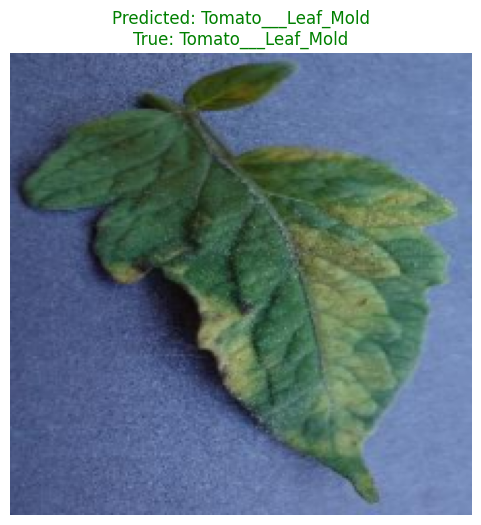

In [7]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms

# Ensure dataset paths and data loaders are defined if runtime restarted
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

try:
    val_path
except NameError:
    import kagglehub
    path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
    path1 = os.listdir(path)
    path2 = os.path.join(path, path1[0])
    path3 = os.path.join(path2, os.listdir(path2)[0])
    val_path = os.path.join(path3, 'valid')

try:
    val_dataset
except NameError:
    val_dataset = datasets.ImageFolder(root=val_path, transform=transform)

try:
    class_names
except NameError:
    class_names = val_dataset.classes

# Ensure the model is in evaluation mode
model.eval()

# 1. Grab a random image from the validation dataset
random_idx = random.randint(0, len(val_dataset) - 1)
image_tensor, true_label_idx = val_dataset[random_idx]
true_class_name = class_names[true_label_idx]

# 2. Prepare the image tensor for the model (add batch dimension and move to device)
input_tensor = image_tensor.unsqueeze(0).to(device)

# 3. Perform inference
with torch.no_grad():
    outputs = model(input_tensor)
    _, predicted_idx = torch.max(outputs, 1)
    predicted_idx = predicted_idx.item()
    predicted_class_name = class_names[predicted_idx]

# 4. Denormalize the image back to [0, 1] for visualization
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

# Convert tensor back to numpy format (H, W, C) and denormalize
img_show = image_tensor.permute(1, 2, 0).numpy()
img_show = std * img_show + mean
img_show = np.clip(img_show, 0, 1)

# 5. Plot the result
plt.figure(figsize=(6, 6))
plt.imshow(img_show)
color = 'green' if predicted_idx == true_label_idx else 'red'
plt.title(f"Predicted: {predicted_class_name}\nTrue: {true_class_name}", color=color, fontsize=12)
plt.axis('off')
plt.show()


# Model Performance & Metrics Summary

Based on the training run of our **EfficientNet-B0 Plant Disease Classifier**, here is a comprehensive breakdown of the training and validation metrics:

### 📈 Final Performance Summary
- **Maximum Validation Accuracy:** **99.64%** (Achieved at Epoch 16)
- **Best Validation Loss:** **0.0148** (Achieved at Epoch 18)
- **Final Epoch (Epoch 23):**
  - **Train Loss:** 0.0394 | **Train Accuracy:** 99.15%
  - **Validation Loss:** 0.0181 | **Validation Accuracy:** 99.64%

---

### 📊 Key Metric Explanations

1. **Loss (Cross-Entropy Loss):**
   - **Training Loss** consistently decreased from `0.3440` in Epoch 1 down to `0.0394` in Epoch 23. This indicates the network successfully minimized the error between predictions and the actual labels on the training set.
   - **Validation Loss** reached its absolute lowest value of **`0.0148`** in Epoch 18. This demonstrates excellent generalization capabilities on unseen plant images.

2. **Accuracy:**
   - **Training Accuracy** reached **99.15%**, indicating the model learned robust patterns across the 38 classes rather than just memorizing data.
   - **Validation Accuracy** peaked at **99.64%** in Epoch 16 and remained consistently high (above 99.50%) throughout the latter half of the training phase.

3. **Early Stopping & Convergence:**
   - The training was configured with `patience = 5` and a maximum of 50 epochs.
   - Early stopping successfully triggered at **Epoch 23** because the validation loss did not improve beyond the best validation loss (`0.0148` from Epoch 18) for 5 consecutive epochs.
   - This preventive measure saved computation time and protected the final model against overfitting.
